# Dataset Import

In [ ]:
import kagglehub
import pandas as pd
import os, math

# Download latest version
path = kagglehub.dataset_download("eshummalik/global-olympic-athletes-performance-dataset")

print("Path to dataset files:", path)

files = os.listdir(path)
print(files)
df_olympic_raw = pd.read_csv(os.path.join(path, files[0]))

df_olympic_raw.head()

Using Colab cache for faster access to the 'global-olympic-athletes-performance-dataset' dataset.
Path to dataset files: /kaggle/input/global-olympic-athletes-performance-dataset
['dataset_olympics.csv']


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


# Amaru's Work

**Imports**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

**Data Analysis and Data Cleaning**

In [ ]:
df_4_ml = df_olympic_raw.copy()

print(f"Shape: {df_4_ml.shape}")
print(f"\nMissing values per column:")
print(df_4_ml.isnull().sum())
print(f"\nMedal breakdown:")
print(df_4_ml['Medal'].value_counts(dropna=False))

df_4_ml.head()

Shape: (70000, 15)

Missing values per column:
ID            0
Name          0
Sex           0
Age        2732
Height    16254
Weight    17101
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal     60310
dtype: int64

Medal breakdown:
Medal
NaN       60310
Gold       3292
Bronze     3208
Silver     3190
Name: count, dtype: int64


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


The columns with missing values are Age, Weight, Height, and Medal. We will inpute the data differently for each.

- Age (less than 5% missing data): Since around 4% of the data in the Age column is missing it is safe to impute with the mean age.

- Weight and Height (more than 10% missing data): Since around 25% of the data in the weight and height columns is missing, it is risky to impute with the overall mean (we risk flattening any pattern in the data). So instead we will calculate the mean value for that sport and sex and impute it with that. This way sport and gender specific patterns will be preserved.

- Medal: Since this is the target column we will fill the NaN values with 0 and the medal (Bronze, Silver, Gold) values with 1, to indicate a positive medal result.


In [ ]:
# Data inputation

# Age
df_4_ml['Age'] = df_4_ml['Age'].fillna(df_4_ml['Age'].mean())

# Height & Weight: group mean by Sport + Sex
for col in ['Height', 'Weight']:
    group_mean = df_4_ml.groupby(['Sport', 'Sex'])[col].transform('mean')
    global_mean = df_4_ml[col].mean()  # fallback if entire group is missing
    df_4_ml[col] = df_4_ml[col].fillna(group_mean).fillna(global_mean)

# Medal: target column: NaN → 0, any medal → 1
df_4_ml['Won_Medal'] = df_4_ml['Medal'].notna().astype(int)

# sanity check on inputations
print("Missing values after imputation:")
print(df_4_ml[['Age', 'Height', 'Weight', 'Won_Medal']].isnull().sum())

Missing values after imputation:
Age          0
Height       0
Weight       0
Won_Medal    0
dtype: int64


Next we will encode the other binary columns (Season: Summer = 1, Winter = 0) and (Sex: Male = 1, Female = 0), since these columns only have two unique values.

In [ ]:
# Encode categorical columns as 0/1
df_4_ml['Sex_enc']    = (df_4_ml['Sex'] == 'M').astype(int)
df_4_ml['Season_enc'] = (df_4_ml['Season'] == 'Summer').astype(int)

**Feature Engineering**

Many of the columns in this dataset (Team, Event, NOC, City, Sport, and Games) are categorical with too many unique values to one hot encode. So instead of ne hot encoding these into hundreds of columns (which would create sparsity and slow the model down), we summarise each into one number: **the historical medal win rate for that group.**

How each column is handled is summarized in the table below:

| Column | Unique Values | Decision |
|--------|-------------|----------|
| `Team` | 827 | Drop → redundant with NOC |
| `Event` | 744 | Engineer → `Event_Medal_Rate` |
| `NOC` | 226 | Engineer → `NOC_Medal_Rate` |
| `City` | 42 | Drop → redundant with Year + Season |
| `Sport` | 65 | Engineer → `Sport_Medal_Rate` |
| `Games` | 51 | Drop → redundant with Year + Season |


In [ ]:
# Sport_Medal_Rate (what fraction of athletes in this sport historically win medals?)
sport_medal_rate = df_4_ml.groupby('Sport')['Won_Medal'].mean().rename('Sport_Medal_Rate')

# NOC_Medal_Rate (how often does this country historically win medals?)
noc_medal_rate = df_4_ml.groupby('NOC')['Won_Medal'].mean().rename('NOC_Medal_Rate')

# Event_Medal_Rate (in this specific event, what fraction of athletes win medals?)
event_medal_rate = df_4_ml.groupby('Event')['Won_Medal'].mean().rename('Event_Medal_Rate')

print("Top 5 sports by medal rate:")
print(sport_medal_rate.sort_values(ascending=False).head())
print("\nTop 5 countries by medal rate:")
print(noc_medal_rate.sort_values(ascending=False).head())
print("\nTop 5 events by medal rate:")
print(event_medal_rate.sort_values(ascending=False).head())

Top 5 sports by medal rate:
Sport
Alpinism         1.0
Rugby            1.0
Basque Pelota    1.0
Cricket          1.0
Lacrosse         1.0
Name: Sport_Medal_Rate, dtype: float64

Top 5 countries by medal rate:
NOC
ANZ    0.434783
URS    0.428809
GDR    0.372477
EUN    0.320988
USA    0.299271
Name: NOC_Medal_Rate, dtype: float64

Top 5 events by medal rate:
Event
Alpinism Mixed Alpinism                                1.0
Archery Men's Pole Archery, Large Birds, Individual    1.0
Archery Men's Pole Archery, Large Birds, Team          1.0
Figure Skating Men's Special Figures                   1.0
Archery Men's Sur La Perche a La Herse                 1.0
Name: Event_Medal_Rate, dtype: float64


From the output we see can see that some sports and events have a perfect medal win rate. This a fictitious result that occurs because these are these are tiny, obscure, one-off entries.  It's not that every athlete always wins, it's that we have almost no data for these sports. A sport with 1 athlete and 1 medal looks like a 100% medal rate, which is meaningless and will mislead the model.

To fix this we will implement a smoothing technique. We will blend the group rate with the overall average, weighted by how many observations we have. Small groups get pulled toward the global average, large groups keep their true rate.

In [ ]:
global_rate = df_4_ml['Won_Medal'].mean()
k = 10  # smoothing factor

def smoothed_medal_rate(df, group_col, target_col, k, global_rate):
    """
    Computes a smoothed target encoding for a categorical column.
    Small groups are pulled toward the global average.
    Large groups retain their true rate.
    """
    stats = df.groupby(group_col)[target_col].agg(['sum', 'count'])
    smoothed = (stats['sum'] + k * global_rate) / (stats['count'] + k)
    return smoothed.rename(f'{group_col}_Medal_Rate')

# Compute smoothed rates for Sport, NOC, and Event
sport_rate = smoothed_medal_rate(df_4_ml, 'Sport', 'Won_Medal', k, global_rate)
noc_rate   = smoothed_medal_rate(df_4_ml, 'NOC',   'Won_Medal', k, global_rate)
event_rate = smoothed_medal_rate(df_4_ml, 'Event', 'Won_Medal', k, global_rate)

# Merge back into the dataframe
df_4_ml = df_4_ml.merge(sport_rate.rename('Sport_Medal_Rate'), on='Sport', how='left')
df_4_ml = df_4_ml.merge(noc_rate.rename('NOC_Medal_Rate'),     on='NOC',   how='left')
df_4_ml = df_4_ml.merge(event_rate.rename('Event_Medal_Rate'), on='Event', how='left')

print(f"Global medal rate: {global_rate:.3f}")
print(f"\nTop 5 sports by smoothed medal rate:")
print(sport_rate.sort_values(ascending=False).head())
print(f"\nTop 5 countries by smoothed medal rate:")
print(noc_rate.sort_values(ascending=False).head())
print(f"\nTop 5 events by smoothed medal rate:")
print(event_rate.sort_values(ascending=False).head())


Global medal rate: 0.138

Top 5 sports by smoothed medal rate:
Sport
Rugby       0.856405
Lacrosse    0.712810
Cricket     0.625404
Polo        0.497538
Alpinism    0.493193
Name: Sport_Medal_Rate, dtype: float64

Top 5 countries by smoothed medal rate:
NOC
URS    0.426411
GDR    0.368260
ANZ    0.344978
EUN    0.310374
USA    0.298964
Name: NOC_Medal_Rate, dtype: float64

Top 5 events by smoothed medal rate:
Event
Rugby Men's Rugby                                   0.856405
Gymnastics Men's Team All-Around, Swedish System    0.799635
Sailing Mixed 12 metres                             0.722074
Lacrosse Men's Lacrosse                             0.712810
Cricket Men's Cricket                               0.625404
Name: Event_Medal_Rate, dtype: float64


**Train/Test Split**

We choose which columns to use as model inputs (`X`), then split into:
- **Training set (80%)**
- **Test set (20%)**

`stratify=y` ensures both sets maintain the same 86/14 class ratio. Without this, the split could be uneven.

In [ ]:
# selected features for training
FEATURES = ['Age', 'Height', 'Weight', 'Sex_enc', 'Season_enc',
            'Year', 'Sport_Medal_Rate', 'NOC_Medal_Rate', 'Event_Medal_Rate']

X = df_4_ml[FEATURES]
y = df_4_ml['Won_Medal']

print(f"Feature matrix X: {X.shape}")
print(f"Target vector y:  {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21, stratify=y
)

print(f"\nTrain: {len(X_train):,} rows  |  Test: {len(X_test):,} rows")
print(f"Medal rate: (Train: {y_train.mean()*100:.1f}%  |  Test: {y_test.mean()*100:.1f}% )")

Feature matrix X: (70000, 9)
Target vector y:  (70000,)

Train: 56,000 rows  |  Test: 14,000 rows
Medal rate: (Train: 13.8%  |  Test: 13.8% )


**Feature Scaling**

Random Forests don't need scaling, they split on thresholds and don't care about magnitude. However, we plan to compare against **Logistic Regression** and **Naive Bayes** later, both of which are sensitive to feature scale. Scaling now means we don't have to think about it per-model later.

In [ ]:
# Standardize the features
scaler = StandardScaler()

# Fit the scaler only on training data, then apply it to both train and test.
# Fitting on the full dataset before splitting would cause a data leakage, where the model obtains information from the test data.
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_test_scaled  = scaler.transform(X_test)       # transform only

# Convert back to DataFrames so feature names are preserved
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURES, index=X_test.index)

**Random Forest Model Training**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,         # 100 decision trees
    max_depth=10,             # max depth per tree
    class_weight='balanced',  # handles 86/14 imbalance automatically
    random_state=21,          # reproducibility
    n_jobs=-1                 # use all CPU cores
)

rf.fit(X_train, y_train)
print("Model done training!")
print(f"   Trees in the forest: {rf.n_estimators}")
print(f"   Features used:       {rf.n_features_in_}")

Model done training!
   Trees in the forest: 100
   Features used:       9


**Model Evaluation**

Since accuracy measures how many predictions were correct out of all predictions made. However, this is misleading for imbalanced data. In our case predicting "no medal" every time gives 86% accuracy.

Instead we look at:
- **Precision**: of predicted medals, how many were real? (avoids false alarms)
- **Recall**:  of actual medals, how many did we catch? (avoids missed detections)
- **F1-score**: harmonic mean of precision & recall
- **ROC-AUC**: this is a performance metric for binary classification problems that measures a model's ability to distinguish between classes across all possible thresholds. It plots True Positive Rate (Sensitivity) against False Positive Rate (1-Specificity), with a higher AUC closer to 1.0 indicating superior classification performance.

We will also be looking at the confusion matrix.
```
              Predicted No Medal   Predicted Medal
Actual No Medal      True Neg.          False Pos.
Actual Medal         False Neg.         True Pos.
```

In [ ]:
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]  # probability of winning a medal

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Medal', 'Medal']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

Classification Report:
              precision    recall  f1-score   support

    No Medal       0.95      0.75      0.84     12062
       Medal       0.32      0.74      0.45      1938

    accuracy                           0.75     14000
   macro avg       0.63      0.74      0.64     14000
weighted avg       0.86      0.75      0.78     14000

ROC-AUC Score: 0.8324


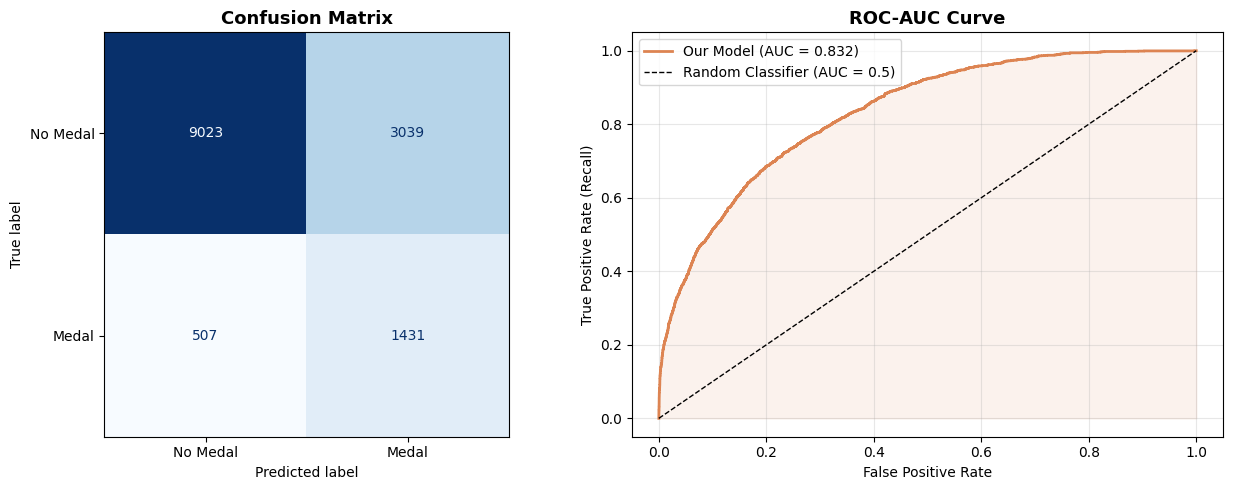


ROC-AUC = 0.832


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Medal', 'Medal'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)

# ROC Curve
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#DD8452', lw=2, label=f'Our Model (AUC = {auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#DD8452')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC-AUC Curve', fontweight='bold', fontsize=13)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"\nROC-AUC = {auc:.3f}")

**Analysis**

The model achieves a ROC-AUC of 0.832, meaning it correctly ranks a medal-winning athlete above a non-medal-winning athlete 83.2% of the time. This is well above the 0.5 baseline of a random classifier, indicating the model has learned genuine signal from the data.

The confusion matrix shows that the model performs well at identifying true negatives (athletes who did not win a medal and were correctly predicted not to). However, the model also has a large number of false positives (cases where the athlete did not win a medal but the model predicted that they did win a medal).

The model is much better at catching actual medal winners (recall = 1431/(1431+507) = 73.8%) than it is at being precise about its medal predictions (precision = 1431/(1431+3039) = 32%). In other words, when the model predicts a medal winner, it's only right about a third of the time, but it catches nearly three quarters of all real medal winners.

This trade-off is a direct consequence of using **'class_weight='balanced'** to handle the class imbalance. The model is tuned to be sensitive to the minority class (medal winners) at the cost of generating more false alarms. Whether this is acceptable depends on the use case. If we assume this model will be used in a scouting or talent identification context, catching real medal contenders matters more than avoiding false positives.

Olympic medal outcomes depend on many factors our dataset doesn't capture, such as competition level on the day, injuries, and head-to-head matchups. This suggests a ceiling on predictive performance that no model trained on this data alone can fully overcome, regardless of how well it is tuned.

# Anant's Work

In [ ]:
df_4_ml.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,...,City,Sport,Event,Medal,Won_Medal,Sex_enc,Season_enc,Sport_Medal_Rate,NOC_Medal_Rate,Event_Medal_Rate
0,1,A Dijiang,M,24.0,180.000000,80.000000,China,CHN,1992 Summer,1992,...,Barcelona,Basketball,Basketball Men's Basketball,NaN,0,1,1,0.242969,0.202269,0.208791
1,2,A Lamusi,M,23.0,170.000000,60.000000,China,CHN,2012 Summer,2012,...,London,Judo,Judo Men's Extra-Lightweight,NaN,0,1,1,0.100370,0.202269,0.060803
2,3,Gunnar Nielsen Aaby,M,24.0,177.480752,73.250232,Denmark,DEN,1920 Summer,1920,...,Antwerpen,Football,Football Men's Football,NaN,0,1,1,0.211978,0.177369,0.202165
3,4,Edgar Lindenau Aabye,M,34.0,182.857143,93.090909,Denmark/Sweden,DEN,1900 Summer,1900,...,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,1,1,1,0.476261,0.177369,0.476261
4,5,Christine Jacoba Aaftink,F,21.0,185.000000,82.000000,Netherlands,NED,1988 Winter,1988,...,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,0,0,0,0.103673,0.183479,0.146288



LOGISTIC REGRESSION MODEL
Best parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}
Best cross-validation ROC-AUC: 0.7971

Test Set Performance:
Accuracy:  0.7239
Precision: 0.2930
Recall:    0.7038
F1-Score:  0.4137
ROC-AUC:   0.7879

5-fold CV ROC-AUC: 0.7971 (+/- 0.0099)

Feature Importance (Logistic Regression):
  Event_Medal_Rate    :   0.8801
  NOC_Medal_Rate      :   0.7079
  Year                :  -0.0574
  Weight              :   0.0506
  Season_enc          :   0.0455
  Age                 :   0.0384
  Height              :   0.0311
  Sex_enc             :   0.0000
  Sport_Medal_Rate    :   0.0000

NAIVE BAYES MODEL

Test Set Performance:
Accuracy:  0.8246
Precision: 0.3624
Recall:    0.3519
F1-Score:  0.3571
ROC-AUC:   0.7627

5-fold CV ROC-AUC: 0.7665 (+/- 0.0165)

MODEL COMPARISON SUMMARY

               Metric  Logistic Regression  Naive Bayes
0           Accuracy               0.7239       0.8246
1          Precision               0.293

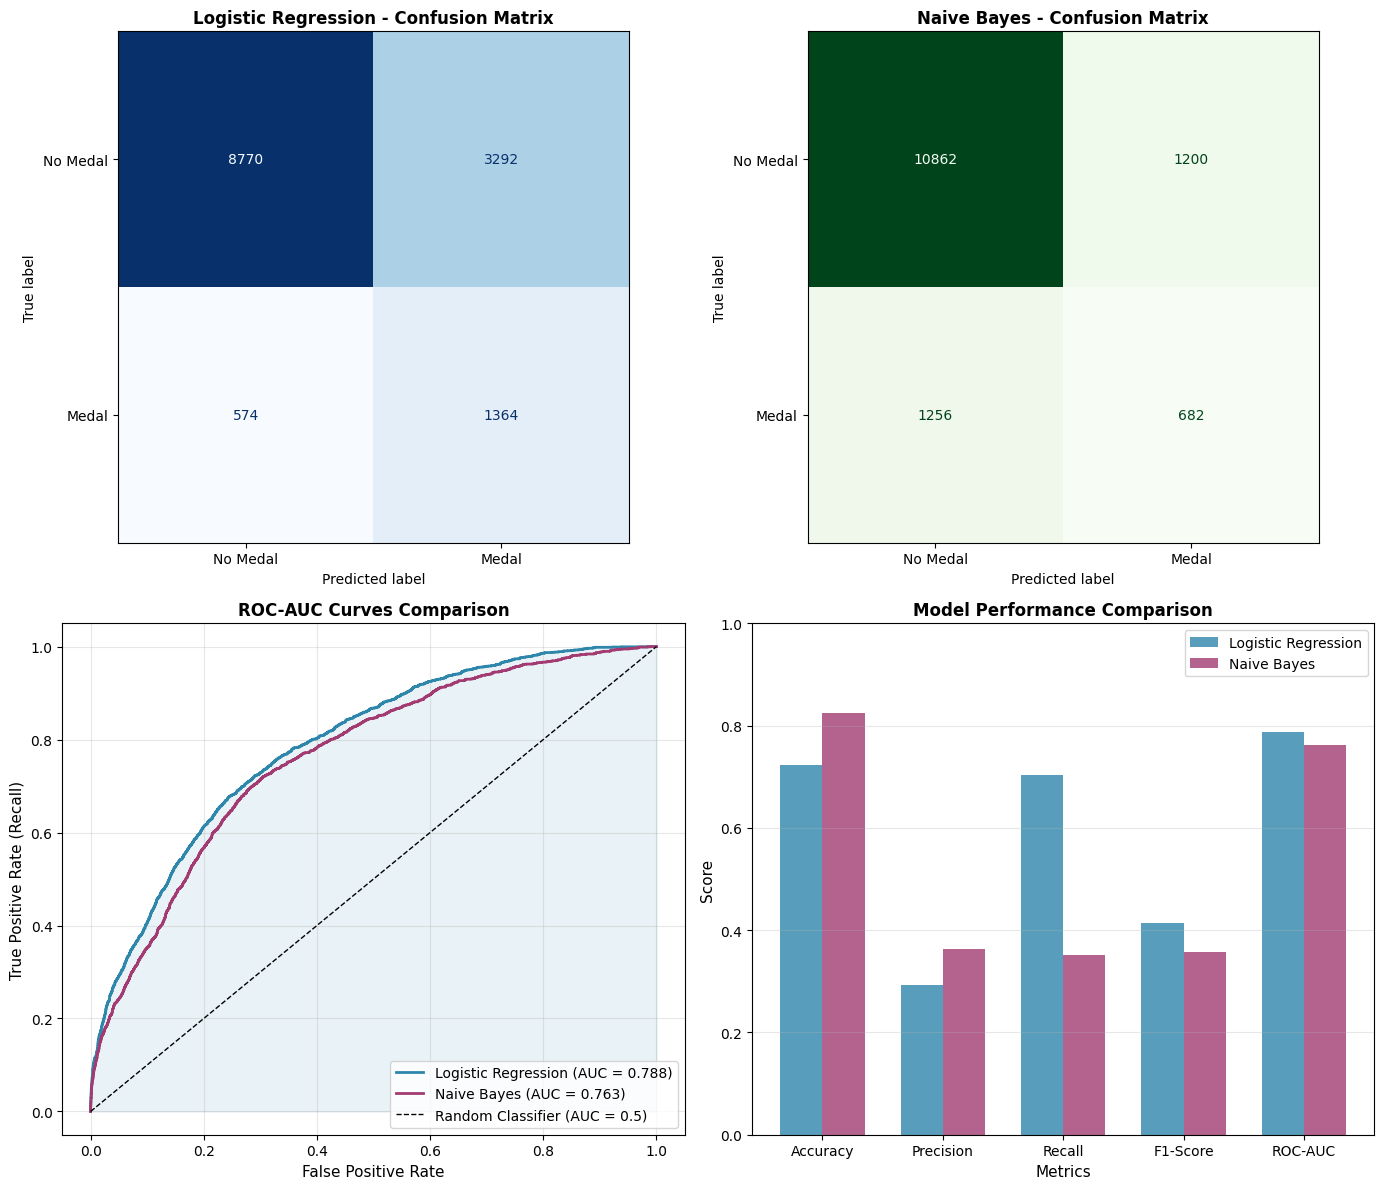


DETAILED CLASSIFICATION REPORTS

Logistic Regression:
              precision    recall  f1-score   support

    No Medal       0.94      0.73      0.82     12062
       Medal       0.29      0.70      0.41      1938

    accuracy                           0.72     14000
   macro avg       0.62      0.72      0.62     14000
weighted avg       0.85      0.72      0.76     14000


Naive Bayes:
              precision    recall  f1-score   support

    No Medal       0.90      0.90      0.90     12062
       Medal       0.36      0.35      0.36      1938

    accuracy                           0.82     14000
   macro avg       0.63      0.63      0.63     14000
weighted avg       0.82      0.82      0.82     14000


CONCLUSIONS & INSIGHTS

Logistic Regression outperforms Naive Bayes for this task because:
   • Features are not independent (e.g., Height and Weight are correlated)
   • Logistic Regression handles feature interactions better
   • Medal rates from different groupings (Sport/

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("\n" + "="*70)
print("LOGISTIC REGRESSION MODEL")
print("="*70)

# Hyperparameter tuning
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', None]
}

lr = LogisticRegression(max_iter=1000, random_state=21)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_lr.best_params_}")
print(f"Best cross-validation ROC-AUC: {grid_lr.best_score_:.4f}")

# Best model
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
y_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("\nTest Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.4f}")

# Cross-validation
cv_scores_lr = cross_val_score(best_lr, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"\n5-fold CV ROC-AUC: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std() * 2:.4f})")

# Feature importance
feature_importance_lr = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': best_lr.coef_[0],
    'Abs_Coefficient': np.abs(best_lr.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("\nFeature Importance (Logistic Regression):")
for idx, row in feature_importance_lr.iterrows():
    print(f"  {row['Feature']:20s}: {row['Coefficient']:8.4f}")

#  NAIVE BAYES
print("\n" + "="*70)
print("NAIVE BAYES MODEL")
print("="*70)

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
y_proba_nb = nb.predict_proba(X_test_scaled)[:, 1]

print("\nTest Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test,y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_nb):.4f}")

# Cross-validation
cv_scores_nb = cross_val_score(nb, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"\n5-fold CV ROC-AUC: {cv_scores_nb.mean():.4f} (+/- {cv_scores_nb.std() * 2:.4f})")

#  MODEL COMPARISON
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV ROC-AUC (Mean)'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_proba_lr),
        cv_scores_lr.mean()
    ],
    'Naive Bayes': [
        accuracy_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_nb),
        roc_auc_score(y_test, y_proba_nb),
        cv_scores_nb.mean()
    ]
})

print("\n", comparison_df.round(4))

# Determine best model
best_model_name = "Logistic Regression" if cv_scores_lr.mean() > cv_scores_nb.mean() else "Naive Bayes"
print(f"\n Best model based on CV ROC-AUC: {best_model_name}")

#  VISUALIZATIONS
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Confusion Matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=['No Medal', 'Medal'])
disp_lr.plot(ax=axes[0, 0], colorbar=False, cmap='Blues')
axes[0, 0].set_title('Logistic Regression - Confusion Matrix', fontweight='bold', fontsize=12)

# Confusion Matrix - Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(cm_nb, display_labels=['No Medal', 'Medal'])
disp_nb.plot(ax=axes[0, 1], colorbar=False, cmap='Greens')
axes[0, 1].set_title('Naive Bayes - Confusion Matrix', fontweight='bold', fontsize=12)

# ROC Curves Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)

axes[1, 0].plot(fpr_lr, tpr_lr, color='#2E86AB', lw=2,
                label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
axes[1, 0].plot(fpr_nb, tpr_nb, color='#A23B72', lw=2,
                label=f'Naive Bayes (AUC = {roc_auc_score(y_test, y_proba_nb):.3f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')
axes[1, 0].fill_between(fpr_lr, tpr_lr, alpha=0.1, color='#2E86AB')
axes[1, 0].set_xlabel('False Positive Rate', fontsize=11)
axes[1, 0].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[1, 0].set_title('ROC-AUC Curves Comparison', fontweight='bold', fontsize=12)
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(alpha=0.3)

# Metrics Comparison Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
lr_scores = [accuracy_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr),
             recall_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr),
             roc_auc_score(y_test, y_proba_lr)]
nb_scores = [accuracy_score(y_test, y_pred_nb), precision_score(y_test, y_pred_nb),
             recall_score(y_test, y_pred_nb), f1_score(y_test, y_pred_nb),
             roc_auc_score(y_test, y_proba_nb)]

x = np.arange(len(metrics))
width = 0.35

axes[1, 1].bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#2E86AB', alpha=0.8)
axes[1, 1].bar(x + width/2, nb_scores, width, label='Naive Bayes', color='#A23B72', alpha=0.8)
axes[1, 1].set_xlabel('Metrics', fontsize=11)
axes[1, 1].set_ylabel('Score', fontsize=11)
axes[1, 1].set_title('Model Performance Comparison', fontweight='bold', fontsize=12)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].legend()
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#  DETAILED CLASSIFICATION REPORTS
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

print("\nLogistic Regression:")
print(classification_report(y_test, y_pred_lr, target_names=['No Medal', 'Medal']))

print("\nNaive Bayes:")
print(classification_report(y_test, y_pred_nb, target_names=['No Medal', 'Medal']))

#  PREDICTION FUNCTION
def predict_medal(athlete_features, model, scaler, model_name="Model"):
    """
    Predict medal winning probability for an athlete

    Parameters:
    - athlete_features: dict with keys from FEATURES list
    - model: trained model (LogisticRegression or GaussianNB)
    - scaler: fitted StandardScaler
    - model_name: name of the model for display
    """
    # Create DataFrame with correct feature order
    features_df = pd.DataFrame([athlete_features])[FEATURES]
    features_scaled = scaler.transform(features_df)
    probability = model.predict_proba(features_scaled)[0, 1]

    print(f"\n{model_name} Prediction:")
    print(f"  Medal Winning Probability: {probability:.4f} ({probability*100:.2f}%)")
    print(f"  Prediction: {' WILL WIN MEDAL' if probability > 0.5 else ' WILL NOT WIN MEDAL'}")

    return probability

#  CONCLUSIONS
print("\n" + "="*70)
print("CONCLUSIONS & INSIGHTS")
print("="*70)

if cv_scores_lr.mean() > cv_scores_nb.mean():
    print("\nLogistic Regression outperforms Naive Bayes for this task because:")
    print("   • Features are not independent (e.g., Height and Weight are correlated)")
    print("   • Logistic Regression handles feature interactions better")
    print("   • Medal rates from different groupings (Sport/NOC/Event) are correlated")
else:
    print("\n Naive Bayes performs competitively because:")
    print("   • Despite feature dependencies, it works well with the smoothed rates")
    print("   • Simpler model with less risk of overfitting")
    print("   • Faster training and prediction")

print("\n Most Important Features (from Logistic Regression):")
for idx, row in feature_importance_lr.head(3).iterrows():
    impact = "positive" if row['Coefficient'] > 0 else "negative"
    print(f"   • {row['Feature']}: {impact} impact (coef: {row['Coefficient']:.4f})")


# Chris' Work

In [ ]:
import numpy as np
import pandas as pd
df_chris = df_olympic_raw.copy()

In [ ]:
#Adding column to indicate whether the athlete won a medal or not
df_chris["Won Medal"] = df_chris["Medal"].notna().astype(int)

In [ ]:
df_chris[["Medal", "Won Medal"]].head()

,Medal,Won Medal
0,NaN,0
1,NaN,0
2,NaN,0
3,Gold,1
4,NaN,0


In [ ]:
#Creating BMI column by converting CM to M and dividing weight in kg by height in meters

df_chris["BMI"] = df_chris["Weight"] / (df_chris["Height"] / 100) ** 2
df_chris[["BMI"]].head()

,BMI
0,24.691358
1,20.761246
2,NaN
3,NaN
4,23.959094


In [ ]:
#Dropping rows with missing BMI values

df_chris = df_chris.dropna(subset=["BMI"])
df_chris

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Won Medal,BMI
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,0,24.691358
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,0,20.761246
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,0,23.959094
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN,0,23.959094
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN,0,23.959094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69992,35654,"Patrick ""Pat"" Fitzsimmons",M,20.0,160.0,56.0,Ireland,IRL,1964 Summer,1964,Summer,Tokyo,Boxing,Boxing Men's Featherweight,NaN,0,21.875000
69993,35655,Riley Fitzsimmons,M,20.0,192.0,93.0,Australia,AUS,2016 Summer,2016,Summer,Rio de Janeiro,Canoeing,"Canoeing Men's Kayak Fours, 1,000 metres",NaN,0,25.227865
69997,35657,"David Thomas ""Dave"" Fitzsimons",M,26.0,170.0,65.0,Australia,AUS,1976 Summer,1976,Summer,Montreal,Athletics,"Athletics Men's 10,000 metres",NaN,0,22.491349
69998,35657,"David Thomas ""Dave"" Fitzsimons",M,30.0,170.0,65.0,Australia,AUS,1980 Summer,1980,Summer,Moskva,Athletics,"Athletics Men's 5,000 metres",NaN,0,22.491349


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

df_chris["medal_binary"] = np.where(df_chris["Medal"].notna(), 1, 0)

X = df_chris[["BMI"]]
y = df_chris["medal_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)


preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print("AUC:", roc_auc_score(y_test, probs))

odds_ratio = np.exp(model.coef_)
print("Odds ratio for BMI:", odds_ratio)

#Class 0 (No medal) results:
# Precision of 0.86 indicates that when the model predicts an athlete will not win a medal, it is correct 86% of the time.
#Recall of 1.00 means that the model correctly identifies all athletes who did not win a medal.
# F1-score of 0.92 is strong, but only because the model predicts "no medal" for almost all athletes, which is not useful for identifying potential medal winners.

#Class 1 (Won medal) results:
# Precision of 0.00 indicates that when the model predicts an athlete will win a medal, it is never correct.
# Recall of 0.00 means the model never predicts “medal” at all.
#F1 score of 0.00 confirms that the model has no ability to identify medal winners

#The end result is that when using Logistic Regression, BMI alone is not a good predictor of winning a medal.

              precision    recall  f1-score   support

           0       0.86      1.00      0.93     11352
           1       0.00      0.00      0.00      1779

    accuracy                           0.86     13131
   macro avg       0.43      0.50      0.46     13131
weighted avg       0.75      0.86      0.80     13131

AUC: 0.5356104774954534
Odds ratio for BMI: [[1.04338424]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df_chris["medal_binary"] = np.where(df_chris["Medal"].notna(), 1, 0)

X = df_chris[["BMI"]]
y = df_chris["medal_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)

print(classification_report(y_test, preds))
print("Feature importance:", rf.feature_importances_)

#Class 0 (No medal) results:
#Precision of 0.87 indicates that when the model predicts an athlete will not win a medal, it is correct 86% of the time.
#Recall of 0.99 means that the model correctly identifies all athletes who did not win a medal.
# F1-score of 0.92 is strong, but only because the model predicts "no medal" for almost all athletes, which is not useful for identifying potential medal winners.

#Class 0 (Won medal) results:
# Precision of 0.31 indicates that when the model predicts an athlete will win a medal, it is correct 31% of the time.
# Recall of 0.02 means the model only finds 2% of real medalists
#F1 score of 0.04 indicates that the model has a very poor ability to identify medal winners

#The end result is that when using Random Forest, BMI alone is a better predictor than logistic regression, but it is still not a good predictor of winning a medal.

              precision    recall  f1-score   support

           0       0.87      0.99      0.92     11352
           1       0.31      0.02      0.04      1779

    accuracy                           0.86     13131
   macro avg       0.59      0.51      0.48     13131
weighted avg       0.79      0.86      0.81     13131

Feature importance: [1.]


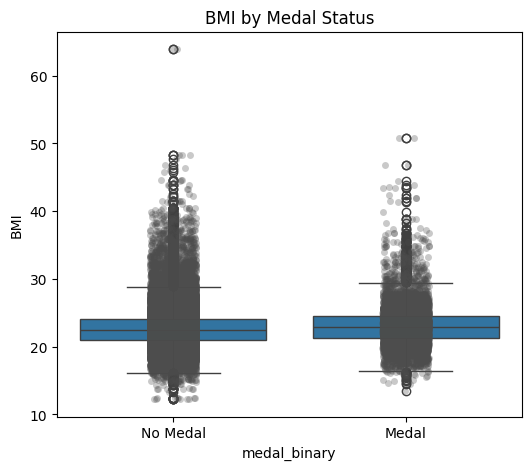

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.boxplot(x="medal_binary", y="BMI", data=df_chris)
sns.stripplot(x="medal_binary", y="BMI", data=df_chris, color="0.3", alpha=0.3, jitter=True)
plt.xticks([0,1], ["No Medal", "Medal"])
plt.ylabel("BMI")
plt.title("BMI by Medal Status")
plt.show()


In [ ]:
#Reasons why BMI may not be a good predictor of winning a medal:
#1: Different sports have different ideal body types. For example, gymnasts may have lower BMIs while weightlifters may have higher BMIs. This variability makes it hard for BMI to be a consistent predictor across all athletes.
#2: Most athletes in a similar sport most likely have similar BMIs, so there may not be enough variation in BMI to distinguish between medal winners and non-winners.
#3: - Medal outcomes depend on skill and technique

# Jereton's Work

### This section analyzes the Olympic athlete data to explore wether hosting the Olympic Games whether hosting the Olympic Games provides an advantage to the host country in terms of medal winnings.

Null Hypothesis (H0): Hosting the Olympics does not increase the probability of winning medals. Alternative Hypothesis (H1): Hosting the Olympics increases the probability of winning medals.

## Cleaning and Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
df_olympic_raw_jerry = df_olympic_raw.copy()
df_olympic_raw_jerry.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [ ]:
df_olympic_raw_jerry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      70000 non-null  int64  
 1   Name    70000 non-null  object 
 2   Sex     70000 non-null  object 
 3   Age     67268 non-null  float64
 4   Height  53746 non-null  float64
 5   Weight  52899 non-null  float64
 6   Team    70000 non-null  object 
 7   NOC     70000 non-null  object 
 8   Games   70000 non-null  object 
 9   Year    70000 non-null  int64  
 10  Season  70000 non-null  object 
 11  City    70000 non-null  object 
 12  Sport   70000 non-null  object 
 13  Event   70000 non-null  object 
 14  Medal   9690 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 8.0+ MB


In [ ]:
# STandardize column names
df_olympic_raw_jerry.columns = df_olympic_raw_jerry.columns.str.strip().str.lower()

# Check for duplicate records
df_olympic_raw_jerry.duplicated().sum()

# remove duplicate records
df_olympic_raw_jerry.drop_duplicates(inplace = True)

# check for missing data
df_olympic_raw_jerry.isna().sum()

,0
id,0
name,0
sex,0
age,2671
height,15876
weight,16718
team,0
noc,0
games,0
year,0


In [ ]:
# Replace null values in the medal column with 'no_medal'
df_olympic_raw_jerry['medal'].fillna('No_medal', inplace=True)

# Create a binary column representing of a medal was won or not
df_olympic_raw_jerry['won_a_medal'] = df_olympic_raw_jerry['medal'].apply(lambda x: 0 if x == 'No_medal' else 1)


# create a dictionary of year and host country
host_dict = {1896: 'GRE', 1900: 'FRA', 1904: 'USA', 1906: 'GRE', 1908: 'GBR', 1912: 'SWE', 1920: 'BEL', 1924: 'FRA',
             1928: 'NED', 1932: 'USA', 1936: 'GER', 1948: 'GBR', 1952: 'FIN', 1956: 'AUS', 1960: 'ITA', 1964: 'JPN',
             1968: 'MEX', 1972: 'GER', 1976: 'CAN', 1980: 'USSR', 1984: 'USA', 1988: 'KOR', 1992: 'ESP', 1994: 'NOR',
             1996: 'USA', 1998: 'JPN', 2000: 'AUS', 2002: 'USA', 2004: 'GRE', 2006: 'ITA', 2008: 'CHN', 2010: 'CAN', 2012: 'GBR',
             2014: 'RUS', 2016: 'BRA'}

# Create a new variable 'host_country' and map to the 'year' variable
df_olympic_raw_jerry['host_country'] = df_olympic_raw_jerry['year'].map(host_dict, na_action = None)

# Create a binary column representing if an athlete is from the host country or not
df_olympic_raw_jerry['from_host_country'] = (df_olympic_raw_jerry['noc'] == df_olympic_raw_jerry.host_country) * 1

# Change variables from object type to category type to make variables more usefull categorical data analysis and reduce data size
object_columns = df_olympic_raw_jerry.select_dtypes(include='object').columns.tolist()
df_olympic_raw_jerry[object_columns] = df_olympic_raw_jerry[object_columns].astype("category")
df_olympic_raw_jerry.head()

/tmp/ipykernel_2473/1519609683.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_olympic_raw_jerry['medal'].fillna('No_medal', inplace=True)


,id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal,won_a_medal,host_country,from_host_country
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No_medal,0,ESP,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No_medal,0,GBR,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No_medal,0,BEL,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,1,FRA,0
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No_medal,0,KOR,0


## Hypothesis Testing

#### Home Country Advantage: Does hosting the Olympic Games provide an advantage for athletes from the host country in winning medals?

In [ ]:
# Determine population average of medal won
df_olympic_raw_jerry.groupby(['from_host_country'])['won_a_medal'].mean()

,won_a_medal
from_host_country,
0,0.13240
1,0.22856


In [ ]:
# Extract host and non-host medal winners population

host_winners = df_olympic_raw_jerry[df_olympic_raw_jerry['from_host_country'] == 1]['won_a_medal']
non_host_winners = df_olympic_raw_jerry[df_olympic_raw_jerry['from_host_country'] == 0]['won_a_medal']

# Perform a t_test on the 2 independent samples
t_statistic, p_value = stats.ttest_ind(host_winners, non_host_winners)

print(f"T.Statistic : {t_statistic}")
print(f"p_value : {p_value}")

T.Statistic : 18.75331649120931
p_value : 2.838875874042777e-78


In [ ]:
# Interpretation of ttest results using a chosen significacance level of 5%

alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis: Host countries have a significant advantage.")
else:
    print("Fail to reject Null: No strong evidence of host advantage.")

Reject Null Hypothesis: Host countries have a significant advantage.


## Visualizations

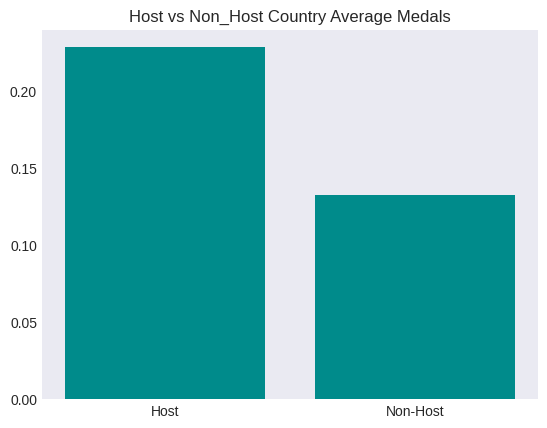

In [ ]:
plt.style.use('seaborn-v0_8-dark')
host_winners_avg = df_olympic_raw_jerry[df_olympic_raw_jerry['from_host_country'] == 1]['won_a_medal'].mean()
non_host_winners_avg = df_olympic_raw_jerry[df_olympic_raw_jerry['from_host_country'] == 0]['won_a_medal'].mean()
x_axis = ['Host', 'Non-Host']
values = [host_winners_avg, non_host_winners_avg]
plt.bar(x_axis, values, width = 0.8, color = 'darkcyan')
plt.title("Host vs Non_Host Country Average Medals")
plt.show()

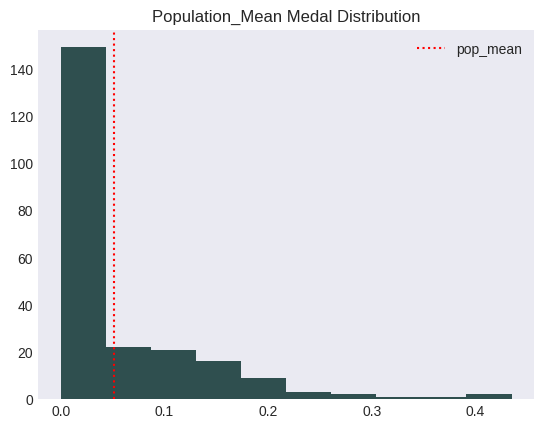

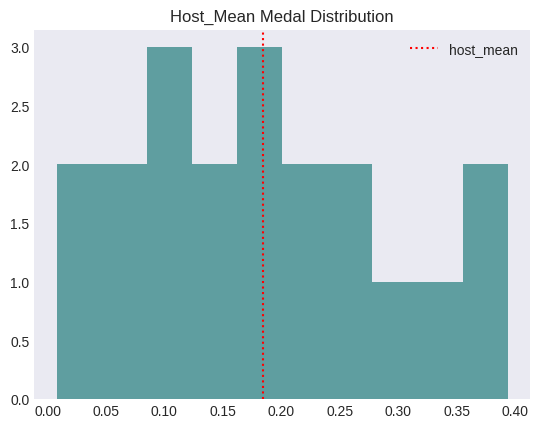

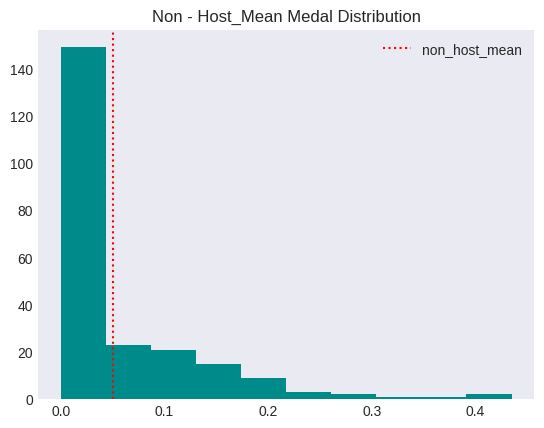

In [ ]:
list_of_countries = df_olympic_raw_jerry['noc'].unique().tolist()
spent_list = []
country_avg_list = []
host_avg_list = []
non_host_avg_list = []

for item in list_of_countries:
    if item in spent_list:
        continue
    pop_avg = df_olympic_raw_jerry[df_olympic_raw_jerry['noc'] == item]['won_a_medal'].mean()
    country_avg_list.append(pop_avg)

    non_host_avg = df_olympic_raw_jerry[(df_olympic_raw_jerry['from_host_country'] == 0) & (df_olympic_raw_jerry['noc'] == item)]['won_a_medal'].mean()
    non_host_avg_list.append(non_host_avg)

    spent_list.append(item)

    host_val = df_olympic_raw_jerry[(df_olympic_raw_jerry['noc'] == item) & (df_olympic_raw_jerry['from_host_country'] == 1)]['won_a_medal']
    if host_val.empty:
        continue
    host_avg = host_val.mean(skipna=True, numeric_only=True)
    host_avg_list.append(host_avg)

country_avg = np.mean(country_avg_list)
host_avg = np.mean(host_avg_list)
non_host_avg = np.mean(non_host_avg_list)

plt.style.use('seaborn-v0_8-dark')

plt.hist(country_avg_list, color = 'darkslategrey')
plt.title("Population_Mean Medal Distribution")

plt.axvline(country_avg, label = "pop_mean", color = 'red', linestyle = ':')
plt.legend()
plt.show()

plt.hist(host_avg_list, color = 'cadetblue')
plt.title("Host_Mean Medal Distribution")

plt.axvline(host_avg, label = "host_mean", color = 'red', linestyle = ':')
plt.legend()
plt.show()

plt.hist(non_host_avg_list, color = 'darkcyan')
plt.title("Non - Host_Mean Medal Distribution")

plt.axvline(non_host_avg, label = "non_host_mean", color = 'red', linestyle = ':')
plt.legend()
plt.show()


## Reports

### Introduction

This section analyzes the Olympic athlete data to explore wether hosting the Olympic Games whether hosting the Olympic Games provides an advantage to the host country in terms of medal winnings. The variables used includes athlete-level information such as country (NOC), year, and medal outcomes.

The dataset was cleaned by standardizing column names, removing duplicate entries and creating two binary variables to indicate if an athlete is from a host country and if they won a medal.

A dictionary of year and host country was also created using a chat gpt model. This helped map host country to the rest of the dataset, since host country was not provided in the original dataset, though host city was provided.

### Hypothesis Testing Methodology

Null Hypothesis (H0): Hosting the Olympics does not increase the probability of winning medals.
Alternative Hypothesis (H1): Hosting the Olympics increases the probability of winning medals.

### Results

The result of the t-test analysis conducted to determine the statistical significance of the relationship bwtween the tested variables showed p_value to be less than the chosen level of significance of 0.05, hence the null hypothesis was safely rejected.

Visualizations showed a consistency in the distribution of medals across the population and sample data for non-host countries, while the average medal won by host countries was significantly more than those of non-host countries, in line with the findings of the hypothesis test.

### Conclusions

Finally this analysis suggests that host countries have an advantage in winning significantly more medals than other countries.

# Paresh's Work
### Age and Medal Probability in Olympic Athletes
##### Research Question: Does an athlete's age affect the probability of winning a medal?
##### Hypotheses:
- H0: Age has no effect on winning a medal
- H1: Athletes within certain age ranges are more likely to win medals


In [ ]:
#
# -------------------------------
# Get copy of data and Create Game_Type (Team vs Individual)
# -------------------------------

df_pm =df_olympic_raw.copy()

# Count athletes per Team + Games + Event
df_pm["Group_Size"] = df_pm.groupby(
    ["Team", "Games", "Event"]
)["Name"].transform("count")

# Assign Game Type
df_pm["Game_Type"] = df_pm["Group_Size"].apply(
    lambda x: "Team" if x > 1 else "Individual"
)

print("\nGame Type Distribution:")
print(df_pm["Game_Type"].value_counts())
print("\nSample Size:")
print(df_pm["Game_Type"].value_counts())



Game Type Distribution:
Game_Type
Individual    35962
Team          34038
Name: count, dtype: int64

Sample Size:
Game_Type
Individual    35962
Team          34038
Name: count, dtype: int64


In [ ]:
# -------------------------------
# Prepare Data for Age vs Medal
# -------------------------------

df_AgeVsMedal = df_pm[["Age", "Medal", "Game_Type"]].dropna(subset=["Age"]).copy()

# Binary variable
df_AgeVsMedal["Won_Medal"] = df_AgeVsMedal["Medal"].notna()

# Split groups
medalists = df_AgeVsMedal[df_AgeVsMedal["Won_Medal"]]["Age"]
non_medalists = df_AgeVsMedal[~df_AgeVsMedal["Won_Medal"]]["Age"]

In [ ]:
# -------------------------------
# Basic Stats
# -------------------------------

age_min = df_AgeVsMedal["Age"].min()
age_max = df_AgeVsMedal["Age"].max()
age_range_bin = math.ceil(age_max - age_min)

print("\nAge Stats:")
print(f"  Age Range:", age_range_bin)
print(f"  Min-Max: {age_min} - {age_max}")
print("\nGame Type Distribution:")
print(df_AgeVsMedal["Game_Type"].value_counts())
print("\nSample Size:")
print(df_AgeVsMedal["Game_Type"].value_counts())


Age Stats:
  Age Range: 77
  Min-Max: 11.0 - 88.0

Game Type Distribution:
Game_Type
Individual    34940
Team          32328
Name: count, dtype: int64

Sample Size:
Game_Type
Individual    34940
Team          32328
Name: count, dtype: int64


In [ ]:
# -------------------------------
# T-test (Overall)
# -------------------------------
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(medalists, non_medalists)

print("\nT-test Results (Overall):")
print("  T-statistic:", t_stat)
print("  P-value:", p_value)


T-test Results (Overall):
  T-statistic: 6.659686816418518
  P-value: 2.765145490590587e-11


In [ ]:
# -------------------------------
# T-test by Game_Type
# -------------------------------

for game_type in ["Individual", "Team"]:
    subset = df_AgeVsMedal[df_AgeVsMedal["Game_Type"] == game_type]

    medalists_sub = subset[subset["Won_Medal"]]["Age"]
    non_medalists_sub = subset[~subset["Won_Medal"]]["Age"]

    if len(medalists_sub) > 0 and len(non_medalists_sub) > 0:
        t_stat, p_value = ttest_ind(medalists_sub, non_medalists_sub)

        print(f"\nT-test for {game_type} Sports:")
        print("  T-statistic:", t_stat)
        print("  P-value:", p_value)


T-test for Individual Sports:
  T-statistic: 6.250246713875759
  P-value: 4.1453022459677316e-10

T-test for Team Sports:
  T-statistic: 1.421889350555241
  P-value: 0.15506802307779252


/tmp/ipykernel_2473/1742999803.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i, 1].legend(title="Medal Outcome", loc="upper right")
/tmp/ipykernel_2473/1742999803.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i, 1].legend(title="Medal Outcome", loc="upper right")


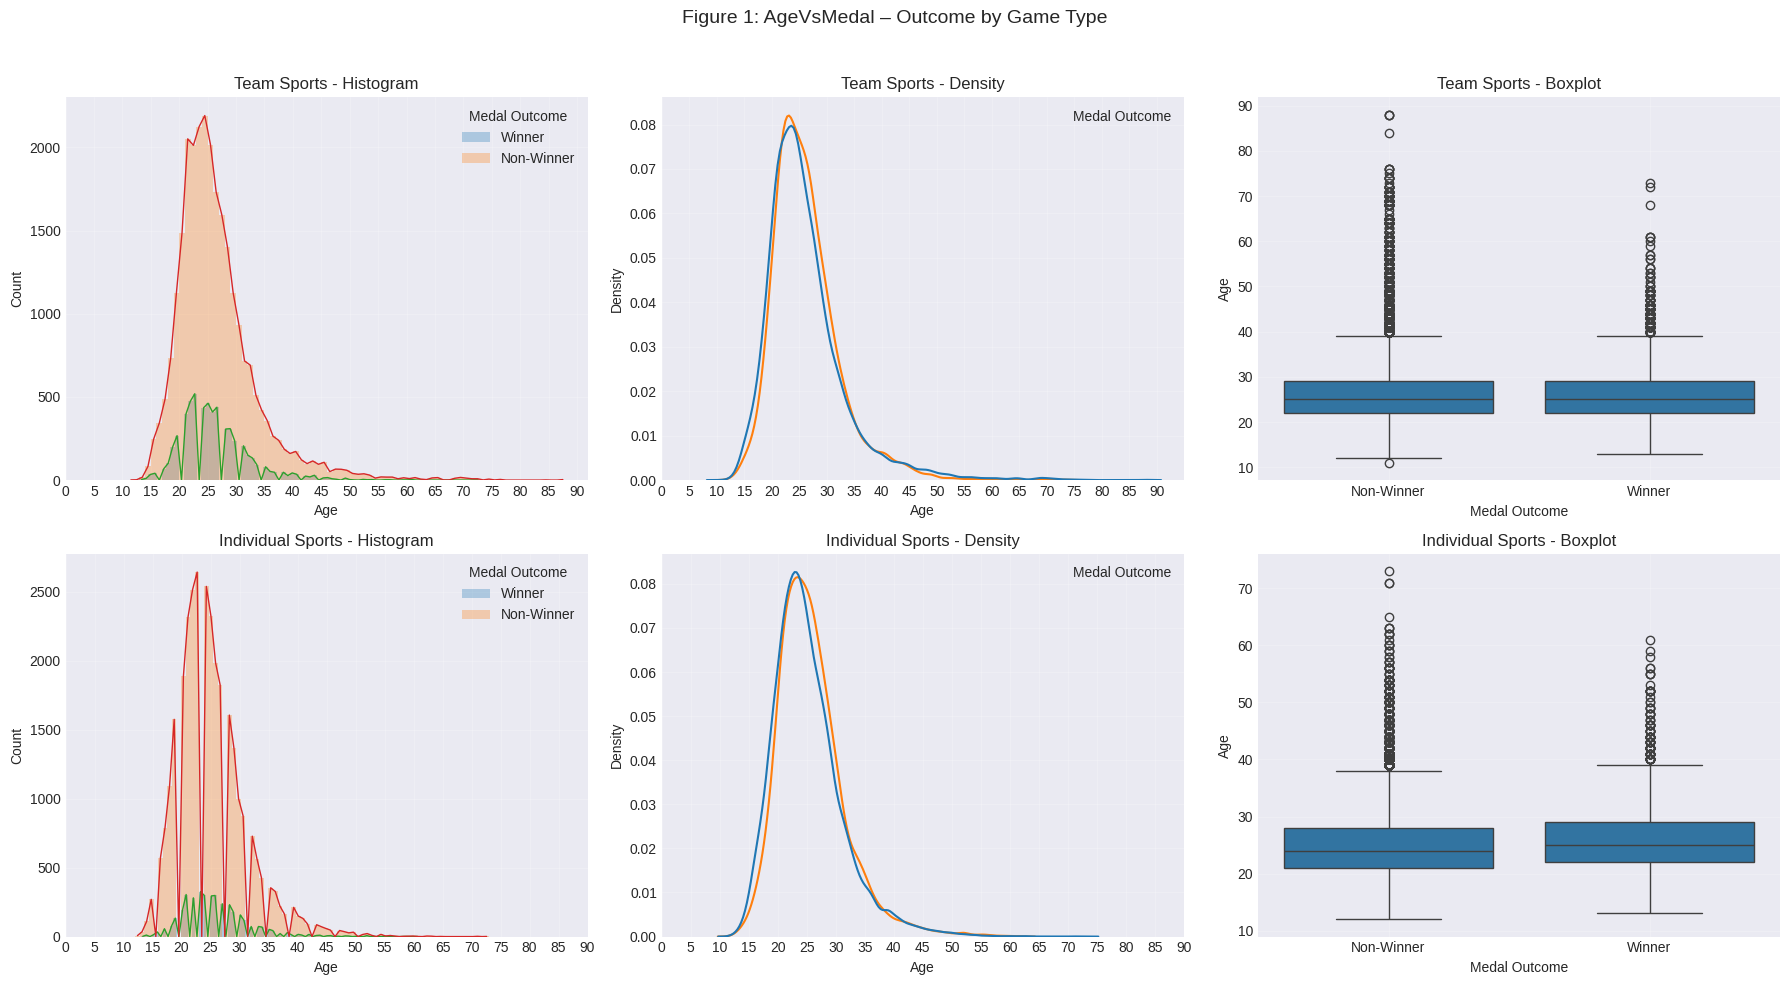

In [ ]:
#
# -------------------------------
# Visualization
# -------------------------------
#

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Label
df_AgeVsMedal["Won Medal Label"] = df_AgeVsMedal["Won_Medal"].map({
    True: "Winner",
    False: "Non-Winner"
})

# Setup 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18,10))

# Overall title
fig.suptitle("Figure 1: AgeVsMedal – Outcome by Game Type", fontsize=14)

xticks = np.arange(0, df_AgeVsMedal["Age"].max() + 5, 5)

# Loop for Team and Individual
for i, game_type in enumerate(["Team", "Individual"]):

    subset = df_AgeVsMedal[df_AgeVsMedal["Game_Type"] == game_type]

    medalists = subset[subset["Won_Medal"]]["Age"]
    non_medalists = subset[~subset["Won_Medal"]]["Age"]

    # -------------------------------
    # 1. Histogram
    # -------------------------------
    counts_w, bins_w, _ = axes[i, 0].hist(
        medalists,
        bins=age_range_bin,
        alpha=0.3,
        label="Winner"
    )

    counts_n, bins_n, _ = axes[i, 0].hist(
        non_medalists,
        bins=age_range_bin,
        alpha=0.3,
        label="Non-Winner"
    )

    # Line overlay
    bin_centers_w = 0.5 * (bins_w[1:] + bins_w[:-1])
    bin_centers_n = 0.5 * (bins_n[1:] + bins_n[:-1])

    axes[i, 0].plot(bin_centers_w, counts_w, linewidth=1.0)
    axes[i, 0].plot(bin_centers_n, counts_n, linewidth=1.0)

    axes[i, 0].set_title(f"{game_type} Sports - Histogram")
    axes[i, 0].set_xlabel("Age")
    axes[i, 0].set_ylabel("Count")
    axes[i, 0].set_xticks(xticks)
    axes[i, 0].grid(True, alpha=0.2)
    axes[i, 0].legend(title="Medal Outcome")

    # -------------------------------
    # 2. KDE
    # -------------------------------
    sns.kdeplot(
        data=subset,
        x="Age",
        hue="Won Medal Label",
        ax=axes[i, 1],
        common_norm=False
    )

    axes[i, 1].set_title(f"{game_type} Sports - Density")
    axes[i, 1].set_xlabel("Age")
    axes[i, 1].set_ylabel("Density")
    axes[i, 1].set_xticks(xticks)
    axes[i, 1].grid(True, alpha=0.2)
    axes[i, 1].legend(title="Medal Outcome", loc="upper right")

    # -------------------------------
    # 3. Boxplot
    # -------------------------------
    sns.boxplot(
        x="Won Medal Label",
        y="Age",
        data=subset,
        ax=axes[i, 2]
    )

    axes[i, 2].set_title(f"{game_type} Sports - Boxplot")
    axes[i, 2].set_xlabel("Medal Outcome")
    axes[i, 2].set_ylabel("Age")
    axes[i, 2].grid(True, alpha=0.2)


# Layout fix (important)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

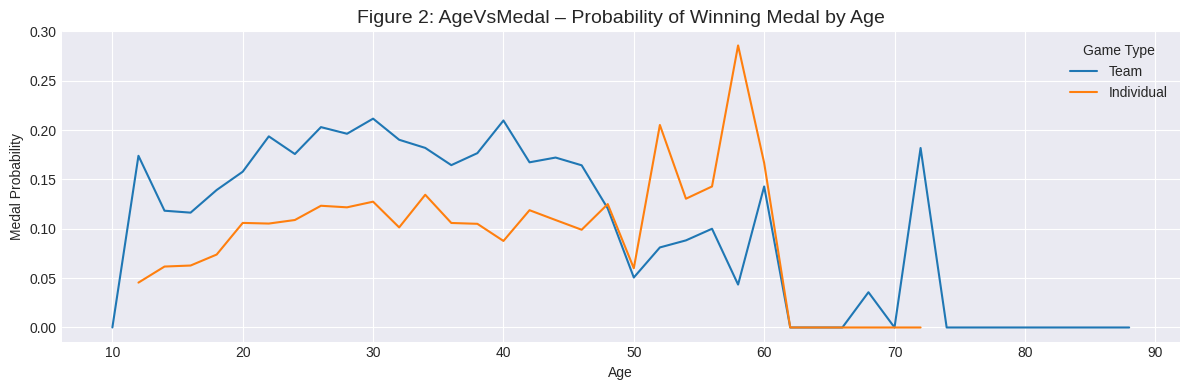

In [ ]:
# -------------------------------
# Medal Probability by Age
# -------------------------------

plt.figure(figsize=(12,4))

df_AgeVsMedal["Age_Bin"] = (df_AgeVsMedal["Age"] // 2) * 2

age_summary = (
    df_AgeVsMedal
    .groupby(["Age_Bin", "Game_Type"])["Won_Medal"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=age_summary,
    x="Age_Bin",
    y="Won_Medal",
    hue="Game_Type"
)

plt.ylabel("Medal Probability")
plt.xlabel("Age")
plt.legend(title="Game Type")
# Figure 1: AgeVsMedal – Probability Curve
plt.title("Figure 2: AgeVsMedal – Probability of Winning Medal by Age", fontsize=14)
plt.tight_layout()
plt.grid(True)
plt.show()

First-Time Winners: 6238
Experienced Winners: 3267

Counts by Game Type:
Game_Type   Experience_Label  
Individual  Experienced Winner    1438
            First-Time Winner     2295
Team        Experienced Winner    1829
            First-Time Winner     3943
dtype: int64

Average Age:
Game_Type   Experience_Label  
Individual  Experienced Winner    28.011822
            First-Time Winner     24.406536
Team        Experienced Winner    28.857299
            First-Time Winner     25.001014
Name: Age, dtype: float64


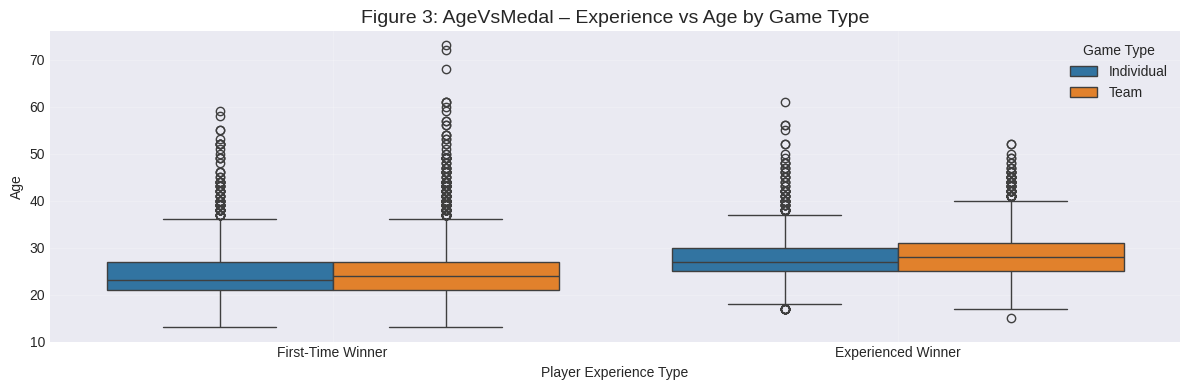

In [ ]:
# Prepare data
df_AgeVsMedal_exp = df_pm[["Name", "Team", "Year", "Age", "Medal", "Game_Type"]].dropna(subset=["Age"]).copy()

# Sort properly
df_AgeVsMedal_exp = df_AgeVsMedal_exp.sort_values(by=["Name", "Team", "Year"])

# Get first participation year for each player
df_AgeVsMedal_exp["First_Year"] = df_AgeVsMedal_exp.groupby(["Name", "Team"])["Year"].transform("min")

# Mark if current row is first-time participation
df_AgeVsMedal_exp["Is_First_Time"] = df_AgeVsMedal_exp["Year"] == df_AgeVsMedal_exp["First_Year"]

# Filter medal winners only
df_medal = df_AgeVsMedal_exp[df_AgeVsMedal_exp["Medal"].notna()].copy()

# Label
df_medal["Experience_Label"] = df_medal["Is_First_Time"].map({
    True: "First-Time Winner",
    False: "Experienced Winner"
})

# Counts
print("First-Time Winners:", (df_medal["Is_First_Time"] == True).sum())
print("Experienced Winners:", (df_medal["Is_First_Time"] == False).sum())
print("\nCounts by Game Type:")
print(df_medal.groupby(["Game_Type", "Experience_Label"]).size())

# Age comparison
print("\nAverage Age:")
print(df_medal.groupby(["Game_Type", "Experience_Label"])["Age"].mean())

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))

sns.boxplot(
    x="Experience_Label",
    y="Age",
    hue="Game_Type",
    data=df_medal
)

plt.legend(title="Game Type")
plt.title("Figure 3: AgeVsMedal – Experience vs Age by Game Type", fontsize=14)
plt.tight_layout()
plt.xlabel("Player Experience Type")
plt.ylabel("Age")
plt.grid(True, alpha=0.2)

plt.show()

# Patrick's Work

In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.stats import chisquare
import statsmodels.api as sm
import statsmodels.formula.api as smf


# !pip install kaggle --quiet


# !mkdir -p ~/.kaggle
# !mv kaggle.json ~/.kaggle/


# !chmod 600 ~/.kaggle/kaggle.json


# kaggle_dataset_identifier = "eshummalik/global-olympic-athletes-performance-dataset"

# # Download the dataset
# print(f"Downloading dataset: {kaggle_dataset_identifier}")
# !kaggle datasets download -d {kaggle_dataset_identifier}

# # Unzip the downloaded file
# print("Unzipping dataset...")
# import glob
# zip_files = glob.glob('*.zip')

# if zip_files:

#     dataset_zip_file = zip_files[0]
#     !unzip -o {dataset_zip_file} -d .
#     print(f"Successfully unzipped {dataset_zip_file}")


#     print("Files after unzipping:")
#     !ls

#     csv_files = glob.glob('*.csv')
#     if csv_files:
#         data_file = csv_files[0]
#         print(f"Loading data from {data_file} into a pandas DataFrame...")
#         try:
#             df = pd.read_csv(data_file)
#             print("Data loaded successfully. Here are the first 5 rows:")
#             print(df.head())
#             print(f"Dataset shape: {df.shape}")
#         except Exception as e:
#             print(f"Error loading CSV: {e}")
#             print("Please check the exact name of the CSV file from the `!ls` output and adjust `data_file` variable if needed.")
#     else:
#         print("No CSV files found after unzipping. Please check the content of the zip file.")
# else:
#     print("No zip files found after download. Please check the dataset identifier and Kaggle API setup.")

df_patrick = df_olympic_raw.copy()

In [ ]:
df_patrick["Got_a_medal"] = df_patrick["Medal"].apply(lambda x: 1 if pd.notnull(x) else 0)
df_patrick

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Got_a_medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,1
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,35656,Stuart Fitzsimmons,M,19.0,NaN,NaN,Great Britain,GBR,1976 Winter,1976,Winter,Innsbruck,Alpine Skiing,Alpine Skiing Men's Giant Slalom,NaN,0
69996,35656,Stuart Fitzsimmons,M,19.0,NaN,NaN,Great Britain,GBR,1976 Winter,1976,Winter,Innsbruck,Alpine Skiing,Alpine Skiing Men's Slalom,NaN,0
69997,35657,"David Thomas ""Dave"" Fitzsimons",M,26.0,170.0,65.0,Australia,AUS,1976 Summer,1976,Summer,Montreal,Athletics,"Athletics Men's 10,000 metres",NaN,0
69998,35657,"David Thomas ""Dave"" Fitzsimons",M,30.0,170.0,65.0,Australia,AUS,1980 Summer,1980,Summer,Moskva,Athletics,"Athletics Men's 5,000 metres",NaN,0


In [ ]:
country_df = (
    df_patrick.groupby("NOC")
      .agg(
          medals=("Got_a_medal", "sum"),
          athletes=("Got_a_medal", "count")
      )
      .reset_index()
)

country_df.head()

,NOC,medals,athletes
0,AFG,0,38
1,AHO,1,33
2,ALB,0,11
3,ALG,4,249
4,AND,0,39


In [ ]:
country_df["medals"].describe()

,medals
count,226.000000
mean,42.876106
std,143.460510
min,0.000000
25%,0.000000
50%,1.000000
75%,12.000000
max,1561.000000


In [ ]:
#equal medal chance

observed = country_df["medals"].values

expected = np.repeat(
    observed.sum() / len(observed),
    len(observed)
)

chi2, p = chisquare(f_obs=observed, f_exp=expected)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p:.4g}")


Chi-square statistic: 108002.03
P-value: 0


equal chance
“Before adjusting for anything, medal outcomes are extremely unequal.”

In [ ]:
#adjusted
total_medals = country_df["medals"].sum()
total_athletes = country_df["athletes"].sum()

country_df["expected_medals"] = (
    total_medals * country_df["athletes"] / total_athletes
)

chi2_adj, p_adj = chisquare(
    f_obs=country_df["medals"],
    f_exp=country_df["expected_medals"]
)

print(f"Adjusted chi-square: {chi2_adj:.2f}")
print(f"Adjusted p-value: {p_adj:.4g}")

Adjusted chi-square: 3865.05
Adjusted p-value: 0


Adjusted
After adjusting for participation - number of medals by number of athletes sent:

Some countries are systematically better or worse at earning medals.

So it's not just that bigger countries send more athletes and therefore have a better chance of winning.

In [ ]:
country_df["std_residual"] = (
    (country_df["medals"] - country_df["expected_medals"]) /
    np.sqrt(country_df["expected_medals"])
)

country_df.sort_values("std_residual", ascending=False).head(10)

,NOC,medals,athletes,expected_medals,std_residual
212,USA,1561,5216,722.043429,31.221792
210,URS,515,1201,166.252714,27.047459
76,GDR,203,545,75.443571,14.685584
79,GER,434,2060,285.162857,8.813834
147,NOR,266,1202,166.391143,7.722054
168,RUS,227,1070,148.118571,6.481418
66,EUN,52,162,22.425429,6.245225
74,GBR,604,3526,488.099143,5.246052
143,NED,272,1480,204.874286,4.689701
41,CHN,122,600,83.057143,4.273063


In [ ]:
country_df.sort_values("std_residual").head(10)

,NOC,medals,athletes,expected_medals,std_residual
60,EGY,5,742,102.714000,-9.641442
160,POR,14,675,93.439286,-8.218084
128,MEX,36,876,121.263429,-7.742797
162,PUR,3,317,43.881857,-6.171463
95,IRL,8,379,52.464429,-6.138754
46,COL,7,339,46.927286,-5.828504
155,PHI,1,239,33.084429,-5.578051
202,TUN,2,233,32.253857,-5.327089
13,AUT,57,814,112.680857,-5.245427
3,ALG,4,249,34.468714,-5.189692


In [ ]:
country_df["log_athletes"] = np.log(country_df["athletes"])

nb_model = smf.glm(
    formula="medals ~ log_athletes",
    data=country_df,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 medals   No. Observations:                  226
Model:                            GLM   Df Residuals:                      224
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -556.65
Date:                Sun, 12 Apr 2026   Deviance:                       217.41
Time:                        17:16:13   Pearson chi2:                     344.
No. Iterations:                     9   Pseudo R-squ. (CS):             0.9901
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -5.2647      0.318    -16.531   

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Negative binomial regression reveals a strong super‑linear relationship between athlete participation and medal outcomes. A 1% increase in participation is associated with a 1.47% increase in medals (p < 0.001), indicating increasing returns to scale. This result implies that larger national delegations convert participation into medals more efficiently, consistent with systematic cross‑country differences in Olympic performance.

Chi‑square (equal medals): Reject Chi‑square (participation‑adjusted): Reject Regression (β > 1): Strongly reject proportionality



Medal counts differ significantly across countries, even after accounting for how many athletes each country sends. A participation‑adjusted chi‑square test rejects proportional medal allocation, and a negative binomial model shows that medals increase more than proportionally with delegation size. This indicates systematic cross‑country differences in Olympic performance.